In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
from models import *

from scipy import stats
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

torch.set_default_dtype(torch.float64)

In [2]:
class Fourier1d(nn.Module):
    def __init__(self, complex_input=False, channels=1, modes=12):
        super(Fourier1d, self).__init__()
        self.weights = nn.Parameter(torch.randn(channels, channels, modes, dtype=torch.cdouble))
        self.linear = nn.Conv1d(channels, channels, 1)
        self.fft = torch.fft.fft if complex_input else torch.fft.rfft
        self.ifft = torch.fft.ifft if complex_input else torch.fft.irfft
        self.complex_input = complex_input
        self.modes = modes

    def forward(self, x):
        batch_size, channels, gridpoints = x.shape
        tmp = self.fft(x)[:, :, :self.modes]   # truncate higher mode
        tmp = torch.einsum('bcm,ocm->bom', tmp, self.weights)
        tmp = self.ifft(tmp, n=gridpoints)   # pad to original input size
        mixing = self.linear(x)
        output =  F.gelu(tmp + mixing)
        return output
    

class FNO1d(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, output_channels=1, complex_input=False, fourier_layers=2, modes=12):
        super(FNO1d, self).__init__()
        model = nn.ModuleList([])
        model.append(nn.Conv1d(input_channels, hidden_channels, 1))
        for _ in range(fourier_layers):
            model.append(Fourier1d(complex_input=complex_input, channels=hidden_channels, modes=modes))

        model.append(nn.Conv1d(hidden_channels, output_channels, 1))

        self.model = nn.Sequential(*model)
    
    def forward(self, x):
        return self.model(x)

In [3]:
class DeepONet(nn.Module):
    def __init__(self, branch_net, trunk_net, branch_dim=2):
        super(DeepONet, self).__init__()
        self.branch_net = branch_net
        self.trunk_net = trunk_net
        self.branch_dim = branch_dim
    
    def forward(self, x):
        qp = x[:, :self.branch_dim]
        time = x[:, self.branch_dim:]
        
        bases = self.branch_net(qp)
        coefficients = self.trunk_net(time)

        return bases * coefficients

        
def init_weights_glorot(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def normalize(x, minimum=None, maximum=None):
    if minimum is None:
        minimum = x.min()
    if maximum is None:
        maximum = x.max()
    return (x - minimum) / (maximum - minimum)

### Data generation

In [12]:
pi = np.pi
lbend = 3

# Create an environment
env = xt.Environment()

env['k1f'] = 0.1
env['k1d'] = -0.7

# Build a simple ring
line = env.new_line(components=[
    env.new('mqf.1', xt.Quadrupole, length=0.3, k1='k1f'),
    env.new('d1.1',  xt.Drift, length=1),
    env.new('mb1.1', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d2.11',  xt.Drift, length=0.3),
    env.new('mof.1', xt.Octupole, length=0.4, k3=0.1), # octupolar perturbation
    env.new('d2.12',  xt.Drift, length=0.3),

    env.new('mqd.1', xt.Quadrupole, length=0.3, k1='k1d'),
    env.new('d3.1',  xt.Drift, length=1),
    env.new('mb2.1', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d4.1',  xt.Drift, length=1),

    env.new('mqf.2', xt.Quadrupole, length=0.3, k1='k1f'),
    env.new('d1.2',  xt.Drift, length=1),
    env.new('mb1.2', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d2.2',  xt.Drift, length=1),

    env.new('mqd.2', xt.Quadrupole, length=0.3, k1='k1d'),
    env.new('d3.2',  xt.Drift, length=1),
    env.new('mb2.2', xt.Bend, length=lbend, k0=pi / 2 / lbend, h=pi / 2 / lbend),
    env.new('d4.2',  xt.Drift, length=1),
])

# Define reference particle
line.particle_ref = xt.Particles(p0c=1.2e9, mass0=xt.PROTON_MASS_EV)

In [13]:
initial_k1f = line['k1f']
initial_k1d = line['k1d']

In [ ]:
np.random.seed(144)
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

parameters = [0.5095, 0.61, 0.71]

n_turns = 1000
record_every = 1
num_particles = 10000
y = np.zeros((num_particles, n_turns//record_every + 1))
py = np.zeros((num_particles, n_turns//record_every + 1))
k1f = np.zeros((num_particles, n_turns//record_every + 1))
k1d = np.zeros((num_particles, n_turns//record_every + 1))

data_y = []
data_py = []
start_time = datetime.now()
for j in range(len(parameters)):
    line['k1f'] = initial_k1f
    line['k1d'] = initial_k1d

    line.match(
            method='4d',
            vary=[
                xt.VaryList(['k1f'], step=1e-8, tag='quad'),
                xt.VaryList(['k1d'], step=1e-8, tag='quad'),
            ],
            targets = [
                xt.TargetSet(qx=1.36, tol=1e-6, tag='tune'),
                xt.TargetSet(qy=parameters[j], tol=1e-6, tag='tune'),
            ])

    final_k1f = line['k1f']
    final_k1d = line['k1d']

    line['k1f'] = initial_k1f
    line['k1d'] = initial_k1d
    
    y_in_sigmas, py_in_sigmas = xp.generate_2D_gaussian(num_particles)

    particles = line.build_particles(
                y_norm=y_in_sigmas, py_norm=py_in_sigmas,
                nemitt_y=13e-6, method = "4d")

    y[:, 0] = particles.y
    py[:, 0] = particles.py
    k1f[:, 0] = line['k1f']
    k1d[:, 0] = line['k1d']
    for i in range(n_turns):
        if (i+1) % record_every == 0:
            k1f[:, i//record_every] = line['k1f']
            k1d[:, i//record_every] = line['k1d']

        line['k1f'] = initial_k1f + (final_k1f - initial_k1f) * i / n_turns
        line['k1d'] = initial_k1d + (final_k1d - initial_k1d) * i / n_turns
        line.track(particles, num_turns=1, freeze_longitudinal=True)

        if (i+1) % record_every == 0:
            y[:, (i+1)//record_every] = particles.y
            py[:, (i+1)//record_every] = particles.py
            k1f[:, (i+1)//record_every] = line['k1f']
            k1d[:, (i+1)//record_every] = line['k1d']

    

    #data_y.append(y.copy())
    #data_py.append(py.copy())

    with open(f'data/simple_line_10k_perturbed_{parameters[j]}.pkl', 'wb') as f:
        pickle.dump((y, py, k1f, k1d), f)

end_time = datetime.now()

# 0:17:53.713859
print(end_time - start_time)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 0.04295                           
Matching: model call n. 18 penalty = 1.3772e-07              
Optimize - end penalty:  1.37724e-07                            
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
                                             
Optimize - start penalty: 1.006                             
Matching: model call n. 21 penalty = 5.5276e-07              
Optimize - end penalty:  5.52765e-07                            
                                             
Optimize - start penalty: 2.005                             
Matching: model call n. 18 penalty = 4.1870e-06              
Optimize - end penalty:  4.18697e-06                            
0:17:53.713859


### DeepONet

In [4]:
# for trajectory data
np.random.seed(144)
inputs = []
targets = []

for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)
        tmp_targets = torch.tensor(np.array([data[0][:, :], data[1][:, :]]))
        
        t = torch.linspace(0, 1, tmp_targets.shape[2]).repeat(tmp_targets.shape[1]).unsqueeze(0)
        
        tmp_inputs = torch.tensor(np.array([data[0][:, 0], data[1][:, 0], data[2][:, -1], data[3][:, -1]]))
        tmp_inputs = torch.repeat_interleave(tmp_inputs, tmp_targets.shape[2], 1)
        #tmp_inputs = torch.cat([tmp_inputs, t, torch.sin(t), torch.cos(t), torch.sin(2*t), torch.cos(2*t), torch.sin(3*t), torch.cos(3*t)], 0)
        
        tmp_targets = tmp_targets.reshape(tmp_targets.shape[0], tmp_targets.shape[1] * tmp_targets.shape[2])

        idx = np.random.choice(range(tmp_inputs.shape[1]), int(1e5), replace=False)

        inputs.append(torch.cat([tmp_inputs[:, idx], t[:, idx], torch.sin(t)[:, idx], torch.cos(t)[:, idx], torch.sin(2*t)[:, idx], torch.cos(2*t)[:, idx]], 0))
        targets.append(tmp_targets[:, idx])

inputs = torch.cat(inputs, dim=1).permute(1, 0)
targets = torch.cat(targets, dim=1).permute(1, 0)

In [5]:
def normalize(x, minimum=None, maximum=None):
    if minimum is None:
        minimum = x.min()
    if maximum is None:
        maximum = x.max()
    return 2 * (x - minimum) / (maximum - minimum) - 1

for i in range(inputs.shape[1]):
    minimum = inputs[:, i].min()
    maximum = inputs[:, i].max()

    inputs[:, i] = normalize(inputs[:, i], minimum, maximum)
    if i < targets.shape[1]:
        targets[:, i] = normalize(targets[:, i], minimum, maximum)

torch.save((inputs, targets), 'data/data_train_simple_line_deeponet_traj.pt')

In [6]:
train_set = TensorDataset(inputs, targets)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)

In [7]:
branch_net =  ResidualNet(4, 64, 64, num_blocks=3, activation=F.tanh)
trunk_net =  ResidualNet(5, 64, 64, num_blocks=5, activation=F.tanh)

model = DeepONet(branch_net, trunk_net, branch_dim=4)

model.apply(init_weights_glorot)

DeepONet(
  (branch_net): ResidualNet(
    (initial_layer): Linear(in_features=4, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-2): 3 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
  (trunk_net): ResidualNet(
    (initial_layer): Linear(in_features=5, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-4): 5 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [8]:
print(inputs.shape)
print(targets.shape)

torch.Size([300000, 9])
torch.Size([300000, 2])


In [9]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-3)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        x, y = batch
        
        outputs = model(x)

        tmp = model(x)
        
        q = torch.sum(tmp[:, :tmp.shape[1]//2], dim=1)
        p = torch.sum(tmp[:, tmp.shape[1]//2:], dim=1)
        outputs = torch.stack([q, p], dim=1)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(train_loader):.8f}")

Epoch 0: loss = 0.06829186
Epoch 1: loss = 0.05754855
Epoch 2: loss = 0.05748144
Epoch 3: loss = 0.05745482
Epoch 4: loss = 0.05740443
Epoch 5: loss = 0.05735635
Epoch 6: loss = 0.05732084
Epoch 7: loss = 0.05729911
Epoch 8: loss = 0.05728129
Epoch 9: loss = 0.05727372
Epoch 10: loss = 0.05726278
Epoch 11: loss = 0.05724949
Epoch 12: loss = 0.05725339
Epoch 13: loss = 0.05724135
Epoch 14: loss = 0.05724461
Epoch 15: loss = 0.05723964
Epoch 16: loss = 0.05724107
Epoch 17: loss = 0.05723839
Epoch 18: loss = 0.05723813
Epoch 19: loss = 0.05723377
Epoch 20: loss = 0.05723040
Epoch 21: loss = 0.05723463
Epoch 22: loss = 0.05723159
Epoch 23: loss = 0.05722659
Epoch 24: loss = 0.05723066
Epoch 25: loss = 0.05723156
Epoch 26: loss = 0.05723045
Epoch 27: loss = 0.05723504
Epoch 28: loss = 0.05722563
Epoch 29: loss = 0.05722757
Epoch 30: loss = 0.05722868
Epoch 31: loss = 0.05722705
Epoch 32: loss = 0.05723666
Epoch 33: loss = 0.05722671
Epoch 34: loss = 0.05722395
Epoch 35: loss = 0.05722829
Ep

In [10]:
torch.save(model.state_dict(), 'deeponet_traj_model.pt')

In [ ]:
# for densities

In [8]:
for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)

    for i in range(2):
        print(np.min(data[i]))
        print(np.max(data[i]))

-0.035514170971423765
0.03557134000384723
-0.006962628879479517
0.006962586662012779
-0.030407302386794604
0.03041704028666099
-0.008439200272780755
0.008354896564816817
-0.03196573343846643
0.032007218843237255
-0.011471168361055904
0.011272496327148222


In [4]:
data = []
for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data.append(pickle.load(f))

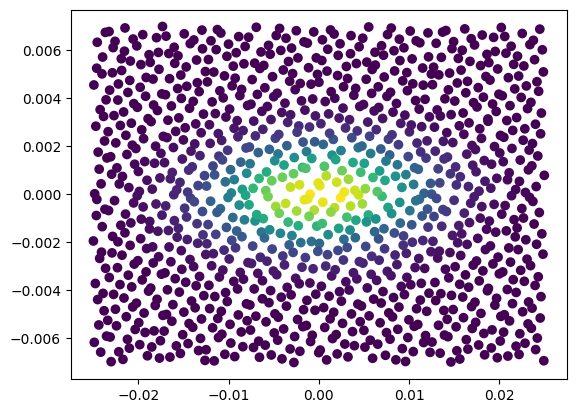

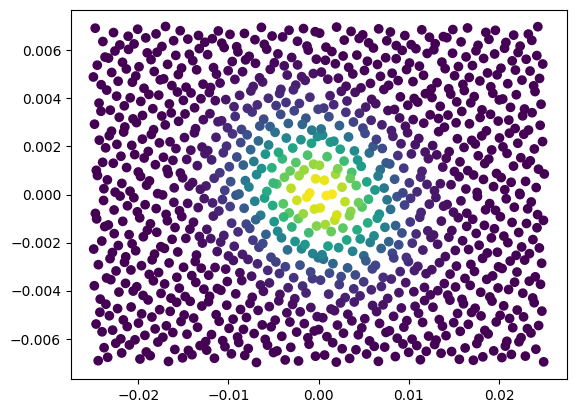

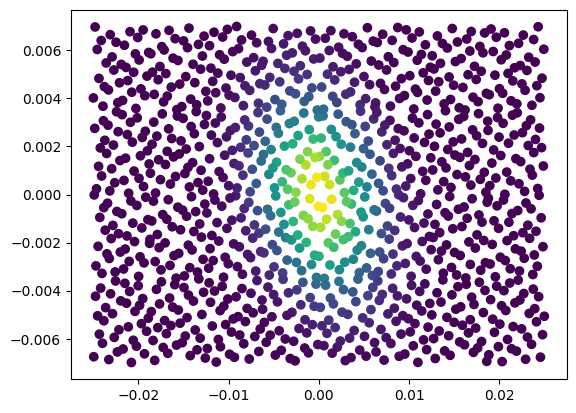

In [5]:
from sklearn.neighbors import KernelDensity

densities = []
positions = []
for i in range(len(data)):
    tmp = []
    pos_tmp = []
    for j in range(data[i][0].shape[1]): # iterate over turns
        soboleng = torch.quasirandom.SobolEngine(dimension=2, scramble=True)
        gridpoints = soboleng.draw(1024)
        gridpoints[:, 0] = (2 * gridpoints[:, 0] - 1) * 0.025   # 0.028 for simple line, 0.008 for PS
        gridpoints[:, 1] = (2 * gridpoints[:, 1] - 1) * 0.007  # 0.007 for simple line, 0.0007 for PS
        gridpoints = gridpoints.permute(1, 0)

        values = np.vstack([data[i][0][:, j], data[i][1][:, j]])
        kde = stats.gaussian_kde(values)
        density = kde(gridpoints)

        gridpoints = gridpoints.permute(1, 0)

        tmp.append(density)
        positions.append(gridpoints)

    plt.scatter(gridpoints[:, 0], gridpoints[:, 1], c=density, cmap='viridis')
    plt.show()    
    densities.append(tmp)

In [6]:
parameters = [0.5095, 0.61, 0.71]

# there are only three unique input densities
inputs_branch = []
targets = []
for i in range(len(densities)):
    inputs_branch.append(parameters[i])
    targets.append(np.expand_dims(np.hstack(densities[i]), 1))

targets = np.vstack(targets)

inputs_branch = np.repeat(inputs_branch, densities[0][0].shape[0] * len(densities[0]))
inputs_branch = np.expand_dims(inputs_branch, 1)

inputs_trunk = np.vstack(positions)
t = np.linspace(0, 1, len(densities[0]))
t = np.repeat(t, densities[0][0].shape[0])
t = np.tile(np.expand_dims(t, 1), (len(densities), 1))
inputs_trunk = np.hstack([inputs_trunk, t])

inputs = np.hstack([inputs_branch, inputs_trunk])

In [7]:
inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

for row in range(inputs.shape[1]):
    inputs[:, row] = normalize(inputs[:, row])

targets = normalize(targets)

In [ ]:
#torch.save((inputs, targets), 'data/data_train_simple_line_deeponet_densities.pt')

In [4]:
inputs, targets = torch.load('data/data_train_simple_line_deeponet_densities.pt')

In [5]:
batch_size = 128

dataset = TensorDataset(inputs, targets)
#trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs_trunk.shape[0]-1, inputs_trunk.shape[0]).astype(int), int(inputs_trunk.shape[0] * 0.2), replace=False))
trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs.shape[0]-1, inputs.shape[0]).astype(int), int(inputs.shape[0] * 0.1), replace=False))
data_loader = DataLoader(trainset, batch_size, True)

In [6]:
from models import *

branch_net =  ResidualNet(1, 64, 64, num_blocks=3, activation=F.relu)
trunk_net = ResidualNet(3, 64, 64, num_blocks=5, activation=F.relu, activate_output=True)

model = DeepONet(branch_net, trunk_net, 1, 1, 64)

# use Glorot initialisation
model.apply(init_weights_glorot)

DeepONet(
  (branch_net): ResidualNet(
    (initial_layer): Linear(in_features=1, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-2): 3 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
  (trunk_net): ResidualNet(
    (initial_layer): Linear(in_features=3, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-4): 5 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-4)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in data_loader:
        optimizer.zero_grad()
        x, y = batch

        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(data_loader):.8f}")

Epoch 0: loss = 0.00190134
Epoch 1: loss = 0.00032842
Epoch 2: loss = 0.00027548
Epoch 3: loss = 0.00023539
Epoch 4: loss = 0.00020363
Epoch 5: loss = 0.00019294
Epoch 6: loss = 0.00018160
Epoch 7: loss = 0.00016956
Epoch 8: loss = 0.00016102
Epoch 9: loss = 0.00015194
Epoch 10: loss = 0.00015212
Epoch 11: loss = 0.00014409
Epoch 12: loss = 0.00014608
Epoch 13: loss = 0.00013971
Epoch 14: loss = 0.00014111
Epoch 15: loss = 0.00013842
Epoch 16: loss = 0.00014136
Epoch 17: loss = 0.00013098
Epoch 18: loss = 0.00013647
Epoch 19: loss = 0.00013214
Epoch 20: loss = 0.00012995
Epoch 21: loss = 0.00012738
Epoch 22: loss = 0.00013370
Epoch 23: loss = 0.00012921
Epoch 24: loss = 0.00012605
Epoch 25: loss = 0.00012538
Epoch 26: loss = 0.00012918
Epoch 27: loss = 0.00012135
Epoch 28: loss = 0.00012608
Epoch 29: loss = 0.00012756
Epoch 30: loss = 0.00012213
Epoch 31: loss = 0.00012324
Epoch 32: loss = 0.00012130
Epoch 33: loss = 0.00012315
Epoch 34: loss = 0.00012432
Epoch 35: loss = 0.00012043
Ep

In [ ]:
torch.save(model.state_dict(), 'deeponet_densities_model.pt')

### Fourier Neural Operator

In [83]:
inputs = []
targets = []

for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)
        tmp_inputs = torch.tensor(np.array([data[0][:, :-1], data[1][:, :-1], data[2][:, 1:], data[3][:, 1:]]))
        #tmp_inputs = tmp_inputs.reshape(tmp_inputs.shape[0], tmp_inputs.shape[1] * tmp_inputs.shape[2])
        inputs.append(tmp_inputs)
        tmp_targets = torch.tensor(np.array([data[0][:, 1:], data[1][:, 1:]]))
        #tmp_targets = tmp_targets.reshape(tmp_targets.shape[0], tmp_targets.shape[1] * tmp_targets.shape[2])
        targets.append(tmp_targets)

inputs = torch.cat(inputs, dim=1).permute(1, 0, 2)
targets = torch.cat(targets, dim=1).permute(1, 0, 2)

In [84]:
np.random.seed(144)
n_samples = 3 * 10**5 
idx_particle = np.random.choice(range(inputs.shape[0]), n_samples, replace=True)
idx_turn = np.random.choice(range(32, inputs.shape[2]-32), n_samples, replace=True)

In [85]:
inputs_train = []
targets_train = []
for i, j in zip(idx_particle, idx_turn):
    inputs_train.append(inputs[i:i+1, :, j-32:j])
    targets_train.append(inputs[i:i+1, :2, j:j+32])

inputs_train = torch.cat(inputs_train, dim=0)
targets_train = torch.cat(targets_train, dim=0)

for i in range(inputs_train.shape[1]):
    minimum = inputs_train[:, i, :].min()
    maximum = inputs_train[:, i, :].max()

    inputs_train[:, i, :] = normalize(inputs_train[:, i, :], minimum, maximum)
    if i < targets_train.shape[1]:
        targets_train[:, i, :] = normalize(targets_train[:, i, :], minimum, maximum)

#torch.save((inputs_train, targets_train), 'data_train_simple_line_fno.pt')

In [86]:
inputs = 0
targets = 0

train_set = TensorDataset(inputs_train, targets_train)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)

In [87]:
model = FNO1d(input_channels=4, hidden_channels=32, output_channels=2, complex_input=False, fourier_layers=6, modes=12)

model.apply(init_weights_glorot)


FNO1d(
  (model): Sequential(
    (0): Conv1d(4, 32, kernel_size=(1,), stride=(1,))
    (1): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (2): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (3): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (4): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (5): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (6): Fourier1d(
      (linear): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
    )
    (7): Conv1d(32, 2, kernel_size=(1,), stride=(1,))
  )
)

In [90]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-4)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        x, y = batch
        
        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(train_loader):.8f}")

Epoch 0: loss = 0.00000165
Epoch 1: loss = 0.00000151
Epoch 2: loss = 0.00000143
Epoch 3: loss = 0.00000136
Epoch 4: loss = 0.00000131
Epoch 5: loss = 0.00000126
Epoch 6: loss = 0.00000121
Epoch 7: loss = 0.00000117
Epoch 8: loss = 0.00000115
Epoch 9: loss = 0.00000111
Epoch 10: loss = 0.00000107
Epoch 11: loss = 0.00000106
Epoch 12: loss = 0.00000103
Epoch 13: loss = 0.00000100
Epoch 14: loss = 0.00000098
Epoch 15: loss = 0.00000097
Epoch 16: loss = 0.00000093
Epoch 17: loss = 0.00000093
Epoch 18: loss = 0.00000091
Epoch 19: loss = 0.00000090
Epoch 20: loss = 0.00000087
Epoch 21: loss = 0.00000086
Epoch 22: loss = 0.00000085
Epoch 23: loss = 0.00000083
Epoch 24: loss = 0.00000082
Epoch 25: loss = 0.00000081
Epoch 26: loss = 0.00000080
Epoch 27: loss = 0.00000078
Epoch 28: loss = 0.00000078
Epoch 29: loss = 0.00000076
Epoch 30: loss = 0.00000075
Epoch 31: loss = 0.00000075
Epoch 32: loss = 0.00000074
Epoch 33: loss = 0.00000072
Epoch 34: loss = 0.00000072
Epoch 35: loss = 0.00000071
Ep

In [91]:
torch.save(model.state_dict(), 'fno_model.pt')

### SympNet

In [ ]:
inputs = []
targets = []

for parameter in [0.5095, 0.61, 0.71]:
    with open(f'data/simple_line_10k_perturbed_{parameter}.pkl', 'rb') as f:
        data = pickle.load(f)
        tmp_inputs = torch.tensor(np.array([data[0][:, :-1], data[1][:, :-1], data[2][:, 1:], data[3][:, 1:]]))
        tmp_inputs = tmp_inputs.reshape(tmp_inputs.shape[0], tmp_inputs.shape[1] * tmp_inputs.shape[2])
        inputs.append(tmp_inputs)
        tmp_targets = torch.tensor(np.array([data[0][:, 1:], data[1][:, 1:]]))
        tmp_targets = tmp_targets.reshape(tmp_targets.shape[0], tmp_targets.shape[1] * tmp_targets.shape[2])
        targets.append(tmp_targets)

inputs = torch.cat(inputs, dim=1).permute(1, 0)
targets = torch.cat(targets, dim=1).permute(1, 0)

In [5]:
for i in range(inputs.shape[1]):
    minimum = inputs[:, i].min()
    maximum = inputs[:, i].max()

    inputs[:, i] = normalize(inputs[:, i], minimum, maximum)
    if i < targets.shape[1]:
        targets[:, i] = normalize(targets[:, i], minimum, maximum)

In [ ]:
np.random.seed(144) 
idx_train = np.random.binomial(1, 0.01, inputs.shape[0]).astype(np.bool) # subsample 1 %
inputs_train = inputs[idx_train, :] 
targets_train = targets[idx_train, :]

inputs_test = inputs[~idx_train, :] 
targets_test = targets[~idx_train, :] 

#torch.save((inputs_train, targets_train), 'data_train_simple_line_sympnet.pt')
#torch.save((inputs_test, targets_test), 'data_val_simple_line_sympnet.pt')

In [6]:
inputs_train, targets_train = torch.load('data/data_train_simple_line_sympnet.pt')

train_set = TensorDataset(inputs_train, targets_train)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)

#test_set = TensorDataset(inputs_test, targets_test)
#test_loader = DataLoader(test_set, batch_size=256, shuffle=True)

In [7]:
la_layers = 5
la_sublayers = 4
input_dim = 2
context_dim = 2

context_nets = []
for i in range(la_layers * la_sublayers):
    tmp = []
    for j in range(la_sublayers):
        tmp.append(MLP(context_dim, [16, 16, 16], (input_dim//2)**2))
    context_nets.append(tmp)

activation_nets = []
for i in range(la_layers-1):
    activation_nets.append(MLP(context_dim, [16, 16, 16], input_dim//2))

model = ConditionalLASympNet(input_dim, context_nets, activation_nets, 5, 4)

model.apply(init_weights_glorot)

ConditionalLASympNet(
  (net): Sequential(
    (0): ConditionalLAModule(
      (net): Sequential(
        (0): ConditionalLALayer(
          (context_net): MLP(
            (net): Sequential(
              (0): Linear(in_features=2, out_features=16, bias=True)
              (1): Tanh()
              (2): Linear(in_features=16, out_features=16, bias=True)
              (3): Tanh()
              (4): Linear(in_features=16, out_features=16, bias=True)
              (5): Tanh()
              (6): Linear(in_features=16, out_features=1, bias=True)
            )
          )
        )
        (1): ConditionalLALayer(
          (context_net): MLP(
            (net): Sequential(
              (0): Linear(in_features=2, out_features=16, bias=True)
              (1): Tanh()
              (2): Linear(in_features=16, out_features=16, bias=True)
              (3): Tanh()
              (4): Linear(in_features=16, out_features=16, bias=True)
              (5): Tanh()
              (6): Linear(in_featur

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-3)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        x, y = batch
        
        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(train_loader):.8f}")

In [9]:
torch.save(model.state_dict(), 'sympnet_model.pt')

### DeepONet densities (different dataset)

In [3]:
#with open('data/density.pkl', 'rb') as f:
#with open('data/density_ps.pkl', 'rb') as f:
with open('data/density_10k.pkl', 'rb') as f:
    data_y, data_py, parameters = pickle.load(f)

In [4]:
for i in range(len(data_y)):
    print(np.min(data_y[i]))
    print(np.max(data_y[i]))

    print(np.min(data_py[i]))
    print(np.max(data_py[i]))

-0.035426719680835037
0.035121505185411794
-0.006872972630721417
0.006877418700890729
-0.029548091301936287
0.0292296455325481
-0.00828520848426041
0.008333842364402771
-0.03105988590618619
0.031097287797775618
-0.010880543880846584
0.010534725025562932


In [5]:
print(data_y[0][:, 0].shape)

(10000,)


In [6]:
histograms = []
for i in range(len(data_y)):
    tmp = []
    for j in range(data_y[i].shape[1]): # iterate over turns
        hist = np.histogram2d(data_y[i][:, j], data_py[i][:, j], bins=32, range=[[-0.008, 0.008], [-0.0007, 0.0007]], density=False, weights=None)
        tmp.append(hist)
    histograms.append(tmp)

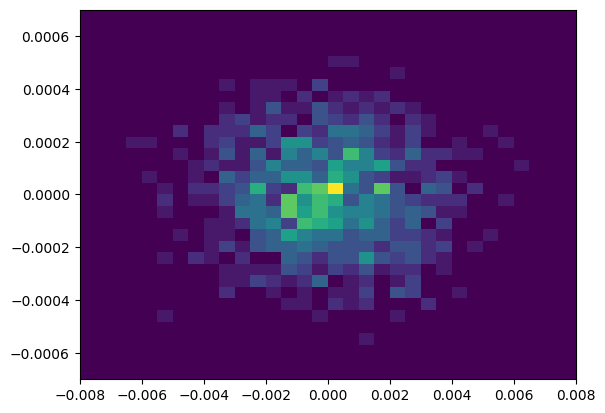

In [45]:
plt.pcolormesh(histograms[0][0][1], histograms[0][0][2], histograms[0][0][0])

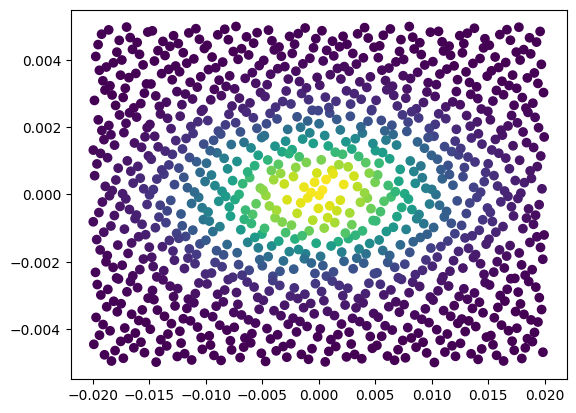

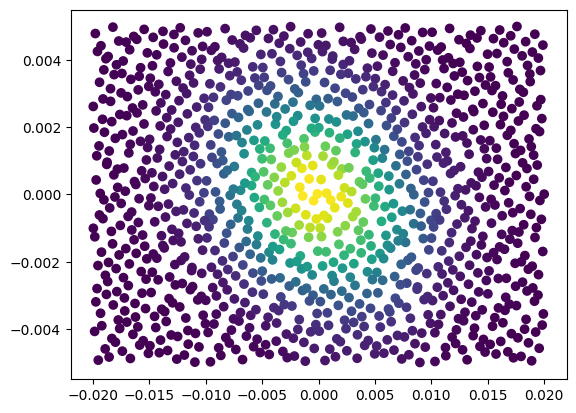

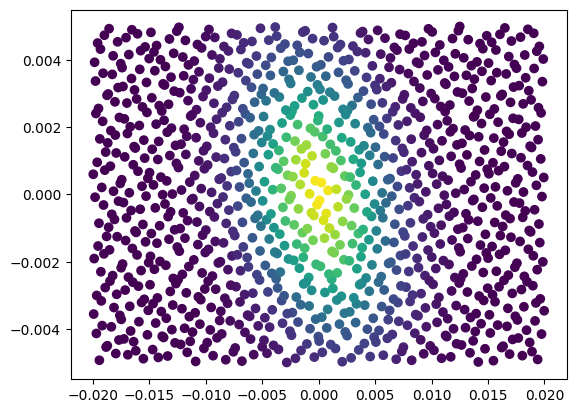

In [7]:
from sklearn.neighbors import KernelDensity

densities = []
positions = []
for i in range(len(data_y)):
    tmp = []
    pos_tmp = []
    for j in range(data_y[i].shape[1]): # iterate over turns
        soboleng = torch.quasirandom.SobolEngine(dimension=2, scramble=True)
        gridpoints = soboleng.draw(1024)
        gridpoints[:, 0] = (2 * gridpoints[:, 0] - 1) * 0.02   # 0.028 for simple line, 0.008 for PS
        gridpoints[:, 1] = (2 * gridpoints[:, 1] - 1) * 0.005  # 0.007 for simple line, 0.0007 for PS
        gridpoints = gridpoints.permute(1, 0)

        values = np.vstack([data_y[i][:, j], data_py[i][:, j]])
        kde = stats.gaussian_kde(values)
        density = kde(gridpoints)

        gridpoints = gridpoints.permute(1, 0)

        tmp.append(density)
        positions.append(gridpoints)

    plt.scatter(gridpoints[:, 0], gridpoints[:, 1], c=density, cmap='viridis')
    plt.show()    
    densities.append(tmp)

In [8]:
# there are only three unique input densities
inputs_branch = []
targets = []
for i in range(len(densities)):
    inputs_branch.append(parameters[i])
    targets.append(np.expand_dims(np.hstack(densities[i]), 1))

targets = np.vstack(targets)

inputs_branch = np.repeat(inputs_branch, densities[0][0].shape[0] * len(densities[0]))
inputs_branch = np.expand_dims(inputs_branch, 1)

inputs_trunk = np.vstack(positions)
t = np.linspace(0, 1, len(densities[0]))
t = np.repeat(t, densities[0][0].shape[0])
t = np.tile(np.expand_dims(t, 1), (len(densities), 1))
inputs_trunk = np.hstack([inputs_trunk, t])

inputs = np.hstack([inputs_branch, inputs_trunk])

In [ ]:
'''
idx = 2
inputs_branch = np.expand_dims(densities[idx][0], 0)
inputs_trunk = np.tile(positions.T, (data_y[idx].shape[1], 1))

t = np.linspace(0, 1, len(densities[idx]))
t = np.repeat(t, densities[idx][0].shape[0])
inputs_trunk = np.hstack([inputs_trunk, np.expand_dims(t, 1)])

targets = np.expand_dims(np.hstack(densities[idx]), 1)

print(inputs_branch.shape)
print(inputs_trunk.shape)
print(targets.shape)
'''

(103424,)
(103424, 2)
(1, 1024)
(103424, 3)
(103424, 1)


In [9]:
#inputs_branch = torch.tensor(inputs_branch)
#inputs_trunk = torch.tensor(inputs_trunk)
#targets = torch.tensor(targets)

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

In [ ]:
'''
inputs_branch = normalize(inputs_branch)
for row in range(inputs_trunk.shape[1]):
    inputs_trunk[:, row] = normalize(inputs_trunk[:, row])

targets = normalize(targets)
'''

In [10]:
for row in range(inputs.shape[1]):
    inputs[:, row] = normalize(inputs[:, row])

targets = normalize(targets)

In [11]:
batch_size = 64

dataset = TensorDataset(inputs, targets)
#trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs_trunk.shape[0]-1, inputs_trunk.shape[0]).astype(int), int(inputs_trunk.shape[0] * 0.2), replace=False))
trainset = torch.utils.data.Subset(dataset, np.random.choice(np.linspace(0, inputs.shape[0]-1, inputs.shape[0]).astype(int), int(inputs.shape[0] * 0.2), replace=False))
data_loader = DataLoader(trainset, batch_size, True)

In [12]:
full_set = TensorDataset(inputs, targets)
test_loader = DataLoader(full_set, batch_size, False)

In [16]:
from models import *

branch_net =  ResidualNet(1, 64, 64, num_blocks=3, activation=F.relu)
trunk_net = ResidualNet(3, 64, 64, num_blocks=5, activation=F.relu, activate_output=True)

#branch_net =  MLP(1024, [512, 256], 32, 'relu')
#trunk_net = MLP(3, [64, 64, 64], 32, 'relu')

model = DeepONet(branch_net, trunk_net, 1, 1, 64)

# use Glorot initialisation
model.apply(init_weights_glorot)

DeepONet(
  (branch_net): ResidualNet(
    (initial_layer): Linear(in_features=1, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-2): 3 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
  (trunk_net): ResidualNet(
    (initial_layer): Linear(in_features=3, out_features=64, bias=True)
    (blocks): ModuleList(
      (0-4): 5 x ResidualBlock(
        (linear_layers): ModuleList(
          (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [17]:
branch = torch.randn(1, 1)          # example image input
trunk = torch.randn(1, 3)        # example image input
print(summary(branch_net, input_data={'inputs': torch.randn(1, 1) }))
print(summary(trunk_net, input_data={'inputs': torch.randn(1, 3) }))

Layer (type:depth-idx)                   Output Shape              Param #
ResidualNet                              [1, 64]                   --
├─Linear: 1-1                            [1, 64]                   128
├─ModuleList: 1-2                        --                        --
│    └─ResidualBlock: 2-1                [1, 64]                   --
│    │    └─ModuleList: 3-3              --                        (recursive)
│    │    └─Dropout: 3-2                 [1, 64]                   --
│    │    └─ModuleList: 3-3              --                        (recursive)
│    └─ResidualBlock: 2-2                [1, 64]                   --
│    │    └─ModuleList: 3-6              --                        (recursive)
│    │    └─Dropout: 3-5                 [1, 64]                   --
│    │    └─ModuleList: 3-6              --                        (recursive)
│    └─ResidualBlock: 2-3                [1, 64]                   --
│    │    └─ModuleList: 3-9              --     

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), 1e-4)

epochs = 100

model.train()
total_loss_epochs = []
for epoch in range(epochs):
    total_losses = 0.0
    for batch in data_loader:
        optimizer.zero_grad()
        x, y = batch
        
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)

        #outputs = torch.einsum('bi,bi->b', branch_output, trunk_output).unsqueeze(1)
        outputs = model(x)
        
        loss = torch.mean((outputs - y)**2)
        loss.backward()
        optimizer.step()

        total_losses += loss.item()
        
    total_loss_epochs.append(total_losses)
    print(f"Epoch {epoch}: loss = {total_losses / len(data_loader):.8f}")

In [22]:
torch.save(model.state_dict(), 'model_density_10k.pt')

In [20]:
model.eval()
total_loss_test = []
max_loss = 0
for batch in test_loader:
    total_losses = 0
    with torch.no_grad():
        x, y = batch
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)
        outputs = model(x)

        #outputs = torch.einsum('bi, bi -> b', branch_output, trunk_output).unsqueeze(1)
        
        loss = torch.abs(outputs - y).max()
        
        if loss > max_loss:
            max_loss = loss
        #print(f"loss = {total_losses:.8f}")
        print(f"max loss = {loss:.8f}")
print(max_loss)

max loss = 0.04033734
max loss = 0.04109673
max loss = 0.04124364
max loss = 0.04575955
max loss = 0.03464941
max loss = 0.03162620
max loss = 0.04103398
max loss = 0.03527566
max loss = 0.04221567
max loss = 0.05388580
max loss = 0.03968303
max loss = 0.03937558
max loss = 0.05423177
max loss = 0.03149353
max loss = 0.03981165
max loss = 0.03715991
max loss = 0.03795592
max loss = 0.03176372
max loss = 0.02895679
max loss = 0.04688809
max loss = 0.04475646
max loss = 0.03654217
max loss = 0.04309769
max loss = 0.03185083
max loss = 0.03648436
max loss = 0.03998836
max loss = 0.03681027
max loss = 0.02726019
max loss = 0.05577934
max loss = 0.04210030
max loss = 0.02908073
max loss = 0.03509888
max loss = 0.03744026
max loss = 0.04860382
max loss = 0.03439766
max loss = 0.04314501
max loss = 0.04329596
max loss = 0.04862460
max loss = 0.04406770
max loss = 0.02981897
max loss = 0.04119806
max loss = 0.05454817
max loss = 0.02650264
max loss = 0.03542419
max loss = 0.04102728
max loss =

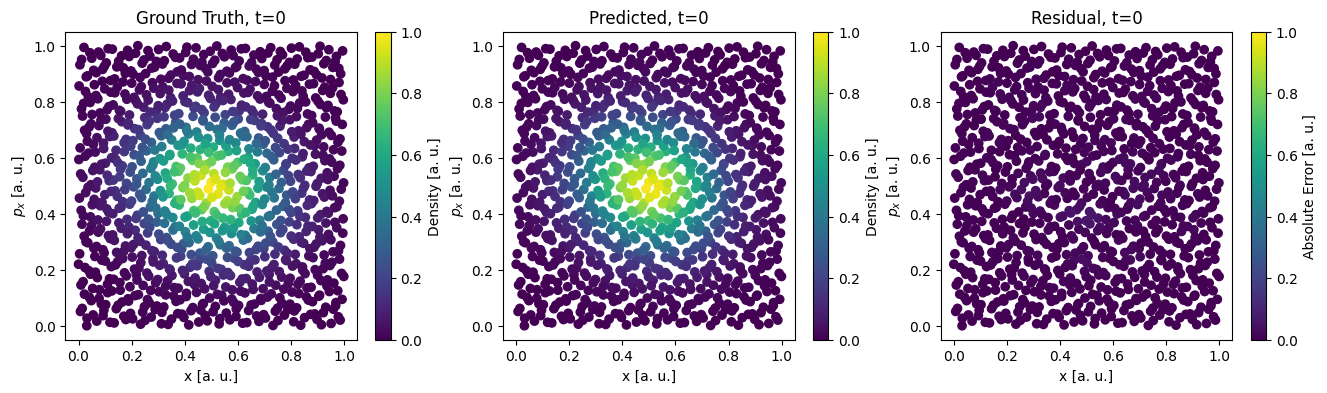

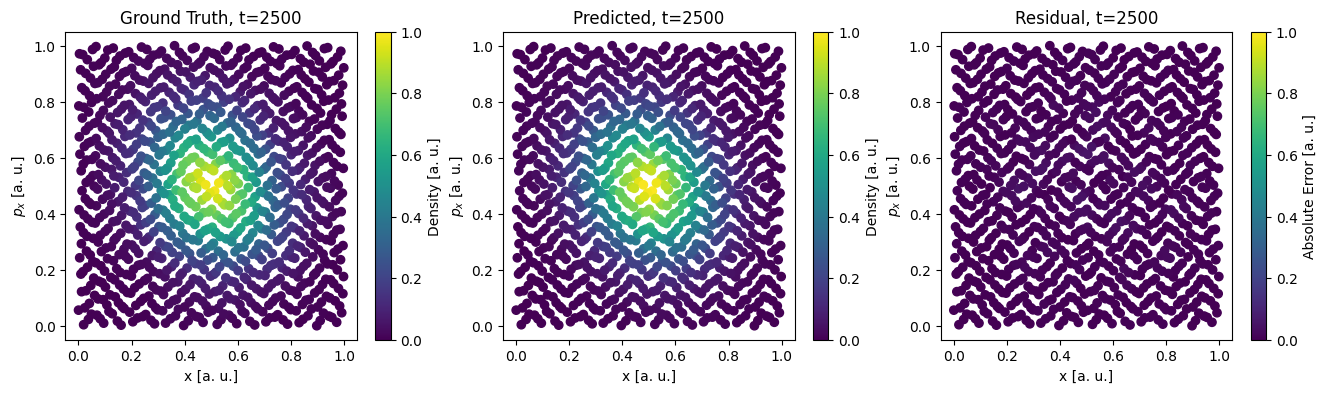

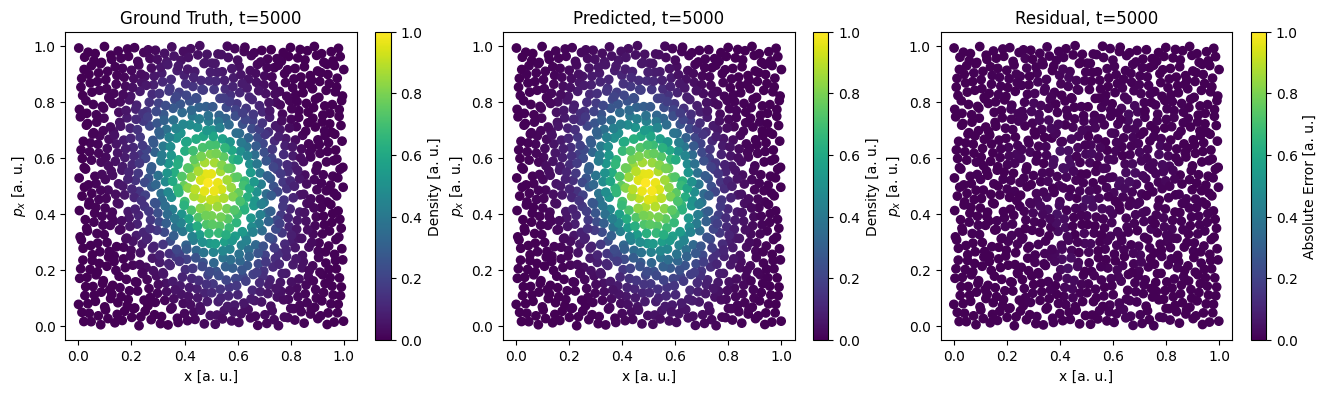

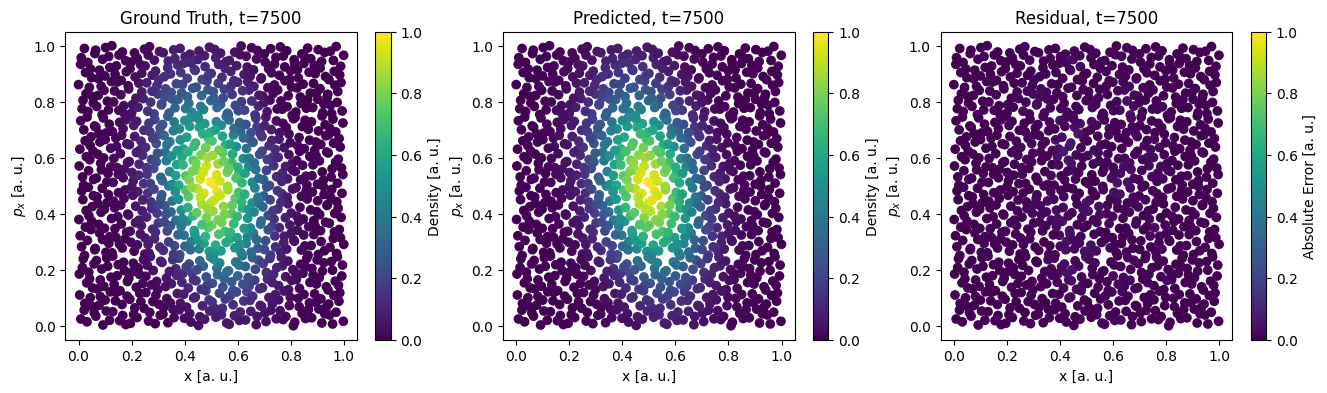

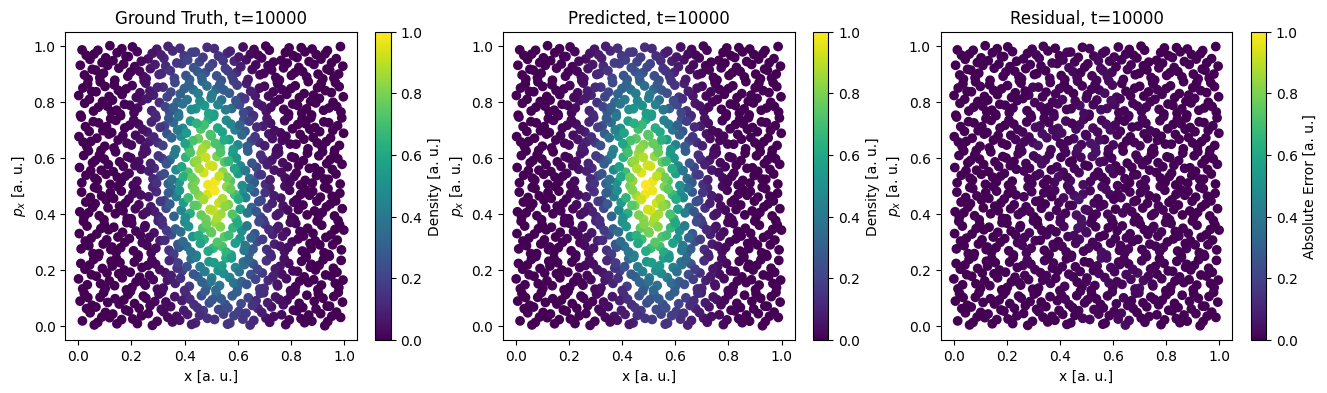

In [23]:
#for i in [0, 25, 50, 75, 100]:
#for i in [101, 125, 150, 175, 201]:
for j in [0, 25, 50, 75, 100]:
    i = j + 202
    with torch.no_grad():
        x = inputs[1024*i:1024*(i+1), :]
        #x = inputs_trunk[1024*i:1024*(i+1), :]
        y = targets[1024*i:1024*(i+1), :]
        #branch_output = branch_net(inputs_branch)
        #trunk_output = trunk_net(x)

        #outputs = torch.einsum('bi,bi -> b', branch_output, trunk_output).unsqueeze(1)
        outputs = model(x)
        difference = torch.abs(outputs - y)

        #plt.pcolormesh(x[:, 0].view(32, 32), x[:, 1].view(32, 32), torch.abs(difference).view(32, 32))
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        sc = ax[0].scatter(x[:, 1], x[:, 2], c=y, cmap='viridis', vmin=0, vmax=1)
        ax[0].set_title(f'Ground Truth, t={j*100}')
        ax[0].set_xlabel('x [a. u.]')
        ax[0].set_ylabel(r'$p_x$ [a. u.]')
        cbar = fig.colorbar(sc, ax=ax[0])
        cbar.set_label('Density [a. u.]')
        sc = ax[1].scatter(x[:, 1], x[:, 2], c=outputs, cmap='viridis', vmin=0, vmax=1)
        cbar = fig.colorbar(sc, ax=ax[1])
        cbar.set_label('Density [a. u.]')
        ax[1].set_title(f'Predicted, t={j*100}')
        ax[1].set_xlabel('x [a. u.]')
        ax[1].set_ylabel(r'$p_x$ [a. u.]')
        sc = ax[2].scatter(x[:, 1], x[:, 2], c=difference, cmap='viridis', vmin=0, vmax=1)
        ax[2].set_title(f'Residual, t={j*100}')
        ax[2].set_xlabel('x [a. u.]')
        ax[2].set_ylabel(r'$p_x$ [a. u.]')
        cbar = fig.colorbar(sc, ax=ax[2])
        cbar.set_label('Absolute Error [a. u.]')
        #ax[0].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), y.view(32, 32))
        #ax[1].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), outputs.view(32, 32))
        #ax[2].pcolormesh(x[:, 1].view(32, 32), x[:, 2].view(32, 32), difference.view(32, 32))